https://www.youtube.com/watch?v=c1coFkBBhhU

In [21]:
import pandas as pd
from sklearn.preprocessing import scale
from minisom import MiniSom

from modulos.mapa import Mapa

In [22]:
mpg_df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv")
mpg_df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger
397,31.0,4,119.0,82.0,2720,19.4,82,usa,chevy s-10


In [23]:
mpg_df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'name'],
      dtype='object')

In [24]:
mpg_df['origin'].unique()

array(['usa', 'japan', 'europe'], dtype=object)

In [25]:

# Remover linhas com qualquer NaN
mpg_df.dropna(inplace=True)

In [26]:
mpg_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 30.6+ KB


In [27]:
features = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year']
labels_contry = mpg_df['name']
X = mpg_df[features].values # apenas números
X = scale(X)

In [28]:
size = 15
som = MiniSom(x=size, y=size, input_len=len(X[0]), sigma=1.5, neighborhood_function='gaussian', random_seed=1)
som.pca_weights_init(X)
som.train_random(X, 1000, verbose=True)

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.5308151196179807


/home/fabiene/anaconda3/envs/YouTube/lib/python3.12/site-packages/minisom.py:447: ComplexWarning: Casting complex values to real discards the imaginary part
  self._weights[i, j] = c1*pc[pc_order[0]] + \


In [29]:
mapa = Mapa(som, X, labels_contry, size)


In [30]:
facility_colors = {
    'usa': '#DC143C', 'japan': '#FFA500', 'europe': '#9370DB',
    #'High facility': '#4B0082'
}
country_start_colors = [facility_colors[facility] for facility in mpg_df['origin'].to_list()]

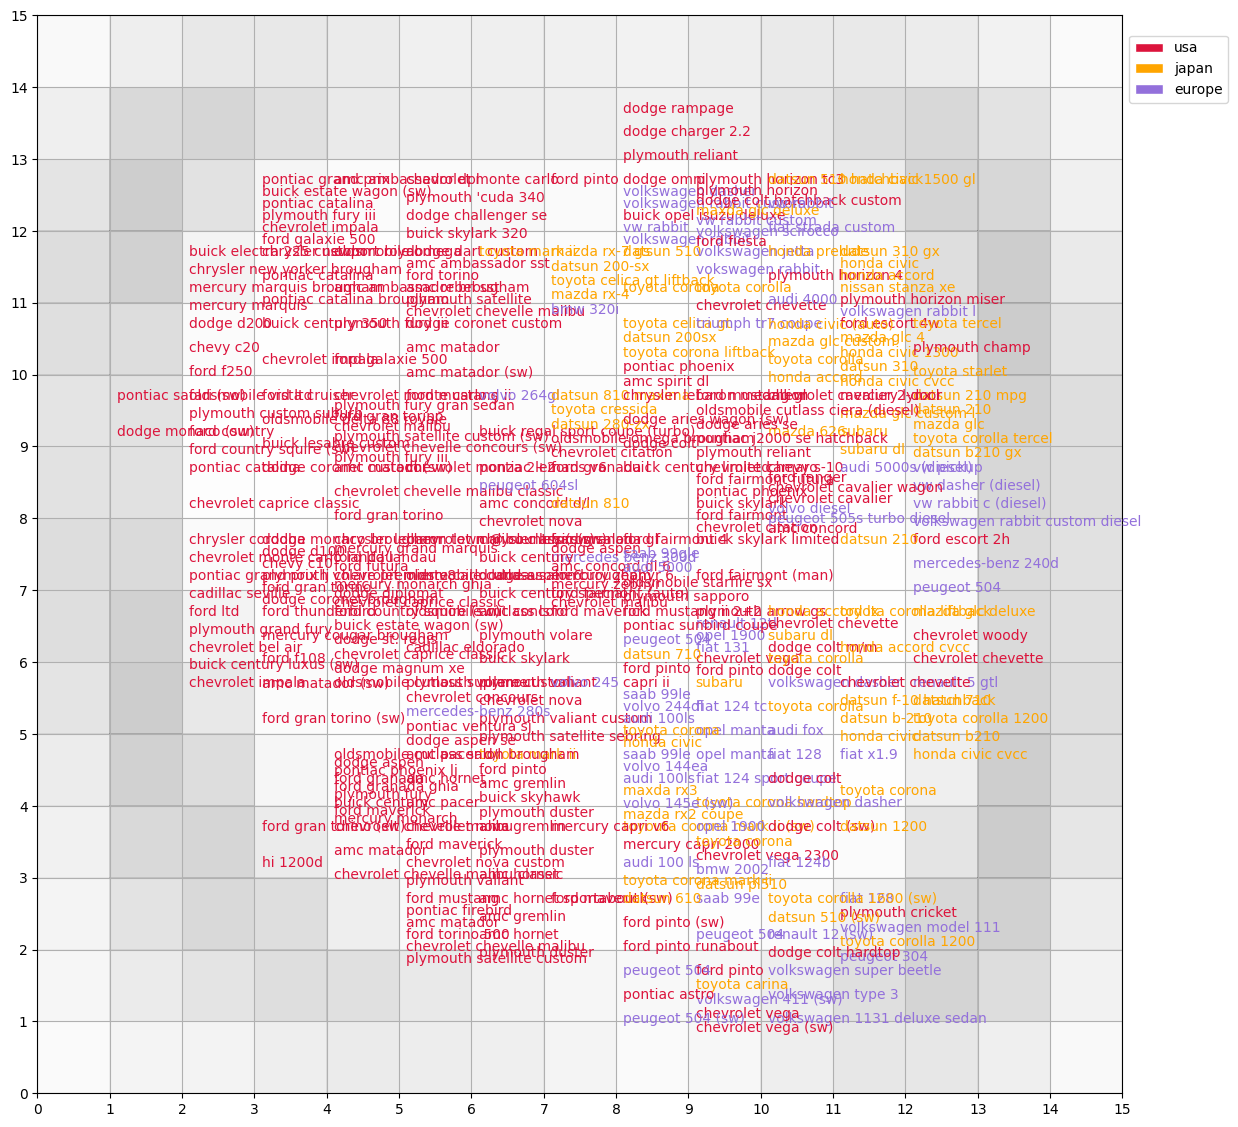

In [31]:
mapa.plot(country_start_colors, facility_colors)
